# FitzHugh–Nagumo model (ODE) solved with RK45

Classic FitzHugh form:

$$
\frac{dv}{dt} = v - \frac{v^3}{3} - w + I_{\text{ext}}, \qquad
\frac{dw}{dt} = \frac{1}{\tau}\,\big(v + a - b\,w\big)
$$

- $v$: membrane potential (fast variable)
- $w$: recovery variable (slow variable)

Integrated with `scipy.integrate.solve_ivp(method="RK45")` (adaptive Dormand–Prince 5(4)).

## Parameters (edit here)

In [1]:
# ---------------- ODE parameters ----------------
a     = 0.7     # recovery offset
b     = 0.8     # recovery damping
tau   = 12.5    # time-scale separation (w is slower for larger tau)
I_ext = 0.5     # external stimulus current

# ---------------- Initial conditions ----------------
v0 = -1.0
w0 = 1.0

# ---------------- Time discretization / solver settings ----------------
t0      = 0.0      # initial time
t_final = 200.0    # final time
n_eval  = 4000     # number of output points (solution is evaluated on this grid)
rtol    = 1e-6     # relative tolerance for RK45
atol    = 1e-9     # absolute tolerance for RK45
max_step = 0.5     # max internal step size (np.inf to let RK45 choose freely)

## Imports and model definition

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def fitzhugh_nagumo(t, y, a, b, tau, I_ext):
    v, w = y
    dv = v - v**3 / 3.0 - w + I_ext
    dw = (v + a - b * w) / tau
    return [dv, dw]

## Solve with RK45

In [3]:
t_eval = np.linspace(t0, t_final, n_eval)

sol = solve_ivp(
    fitzhugh_nagumo,
    t_span=(t0, t_final),
    y0=[v0, w0],
    method="RK45",
    t_eval=t_eval,
    args=(a, b, tau, I_ext),
    rtol=rtol,
    atol=atol,
    max_step=max_step,
)

print(sol.message)
print(f"Function evaluations: {sol.nfev}")
t, v, w = sol.t, sol.y[0], sol.y[1]

The solver successfully reached the end of the integration interval.
Function evaluations: 3602


## Time series

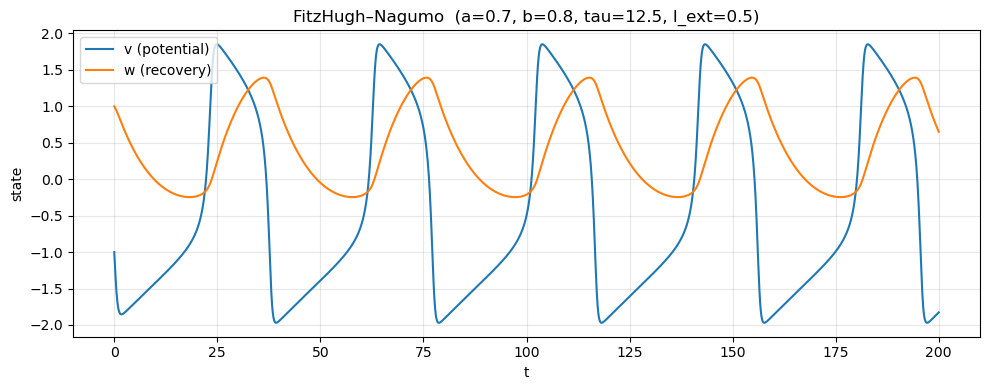

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, v, label="v (potential)")
ax.plot(t, w, label="w (recovery)")
ax.set_xlabel("t")
ax.set_ylabel("state")
ax.set_title(f"FitzHugh–Nagumo  (a={a}, b={b}, tau={tau}, I_ext={I_ext})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
np.savez("fitzhugh_nagumo_solution.npz", t=t, v=v, w=w)

## Phase plane

Nullclines: $w = v - v^3/3 + I_{\text{ext}}$ ($\dot v = 0$) and $w = (v + a)/b$ ($\dot w = 0$).

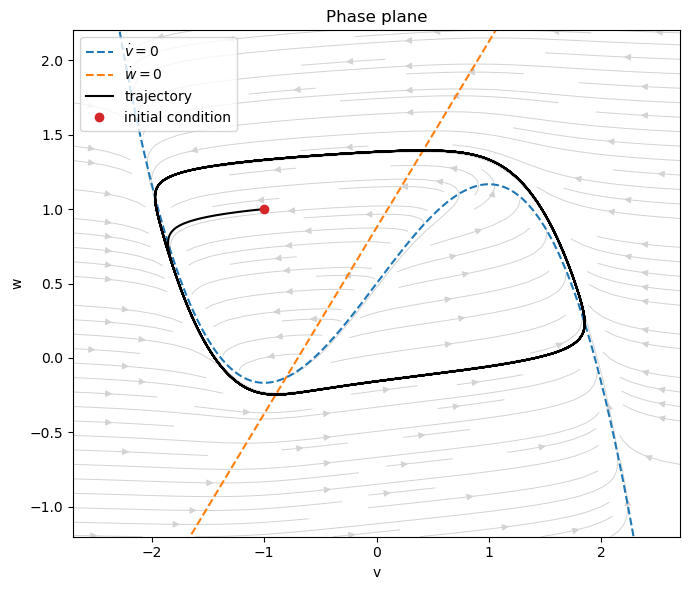

In [5]:
v_min, v_max = min(v.min(), -2.5) - 0.2, max(v.max(), 2.5) + 0.2
w_min, w_max = min(w.min(), -1.0) - 0.2, max(w.max(), 2.0) + 0.2

vv = np.linspace(v_min, v_max, 400)
V, W = np.meshgrid(np.linspace(v_min, v_max, 25), np.linspace(w_min, w_max, 25))
dV, dW = fitzhugh_nagumo(0, [V, W], a, b, tau, I_ext)

fig, ax = plt.subplots(figsize=(7, 6))
ax.streamplot(V, W, dV, dW, color="lightgray", density=1.2, linewidth=0.7)
ax.plot(vv, vv - vv**3 / 3 + I_ext, "--", label=r"$\dot v = 0$")
ax.plot(vv, (vv + a) / b, "--", label=r"$\dot w = 0$")
ax.plot(v, w, "k", lw=1.5, label="trajectory")
ax.plot(v0, w0, "o", color="tab:red", label="initial condition")
ax.set_xlim(v_min, v_max)
ax.set_ylim(w_min, w_max)
ax.set_xlabel("v")
ax.set_ylabel("w")
ax.set_title("Phase plane")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

array([0.00000000e+00, 5.00125031e-02, 1.00025006e-01, ...,
       1.99899975e+02, 1.99949987e+02, 2.00000000e+02], shape=(4000,))